RNN and MLP Performance Analysis Based on Number of Trajectories

Results observation: The RNN benefitted significantly more from increasing the number of training trajectories than the MLP did. This suggests that the RNN was able to obtain a more complete picture of the gridworld and thus be more aware of its position.

In [68]:
import os
import sys

REMOTE_PROJECT = "/mnt/d/remote/Levenstein"

os.chdir(REMOTE_PROJECT)

if REMOTE_PROJECT not in sys.path:
    sys.path.insert(0, REMOTE_PROJECT)

print("Running from:", os.getcwd())
print(os.listdir())

Running from: /mnt/d/remote/Levenstein
['.gitgnore', '.venv', '.vscode', 'Experiments', 'functions', 'gridworld_experiment_SimpleMLP.py', 'loss.png', 'plot.png', 'Pytorch Tutorial', 'Sequential predictive learning is a unifying theory for hippocampal representation.pdf', '__pycache__']


In [69]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [58]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from IPython.display import display, Markdown
import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import functions.dataset_generator as dataset_generator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/sebil/miniconda3/envs/main/bin/python
2.10.0+cu128


State variables

In [59]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2

N_STEPS = 500
N_TRAJ = 20

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]
ACTION_PROBS_TURN_HEAVY = [0.3, 0.35, 0.35, 0.0]

SEED = 42
TRAINER_MOVE_SEED = 100
TRAINER_START_SEED = 150
VALIDATOR_MOVE_SEED = 300
VALIDATOR_START_SEED = 350

TEST_SEED = 123
TEST_STEPS = 200

TRAINING_EPOCHS = 3000

Gridworld Creation

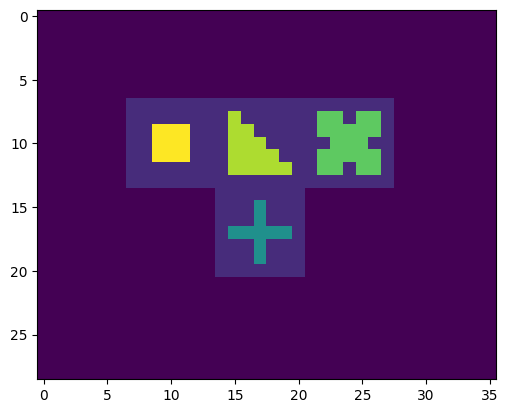

In [60]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
plt.imshow(grid.grid)


NN Training and Validation

Number of trajectories: 20
MLP Trainer final loss: 0.8302754163742065
MLP Validator final loss: 0.9750019311904907


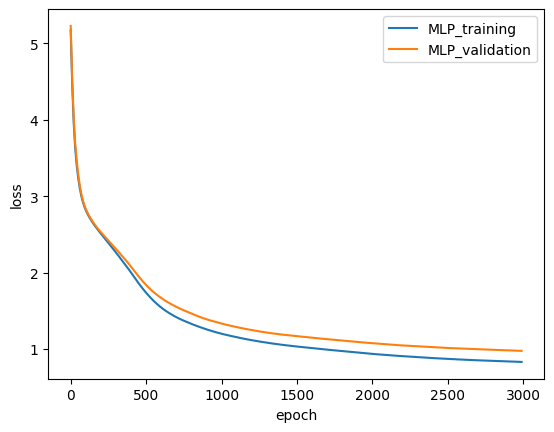

RNN Trainer final loss: 0.7477728128433228
RNN Validator final loss: 0.9398342370986938


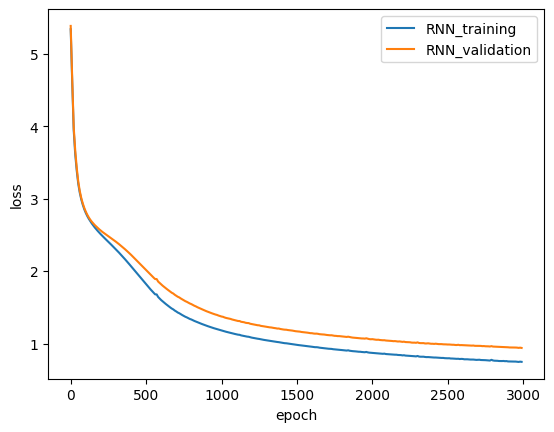

Baseline loss:  4.591728210449219
Baseline loss:  4.676159858703613
Number of trajectories: 40
MLP Trainer final loss: 0.8775317668914795
MLP Validator final loss: 0.9489661455154419


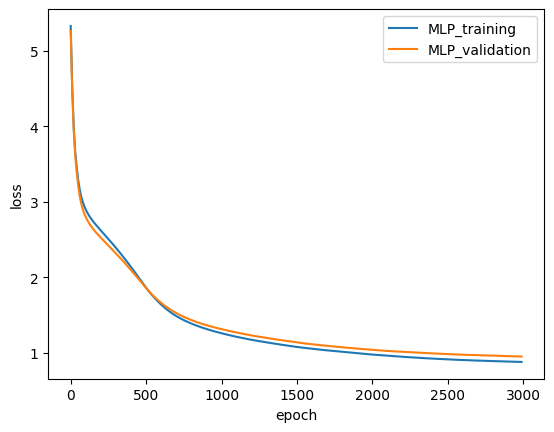

RNN Trainer final loss: 0.7594860196113586
RNN Validator final loss: 0.8458658456802368


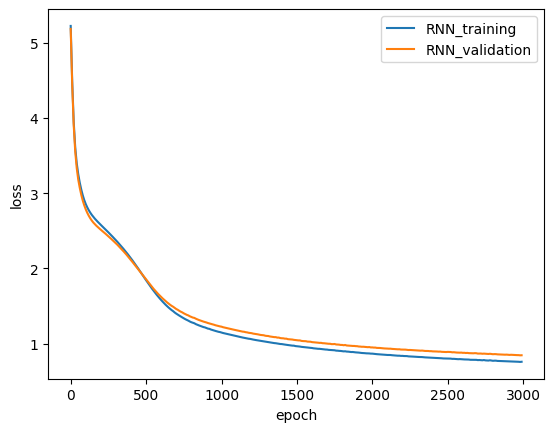

Baseline loss:  4.7241621017456055
Baseline loss:  4.676159858703613
Number of trajectories: 80
MLP Trainer final loss: 0.8417952656745911
MLP Validator final loss: 0.9225548505783081


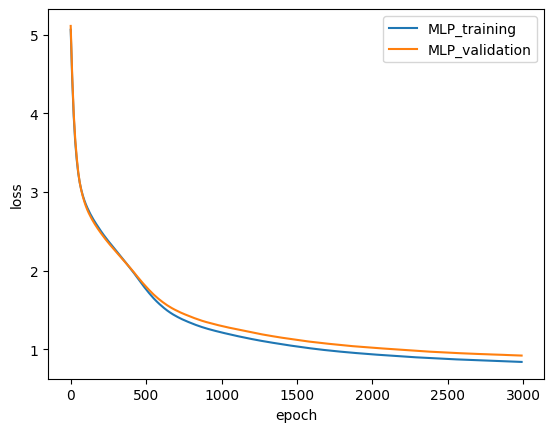

RNN Trainer final loss: 0.7466760873794556
RNN Validator final loss: 0.8187898993492126


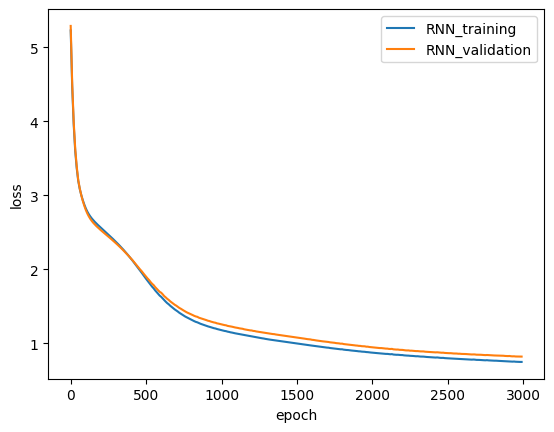

Baseline loss:  4.626364231109619
Baseline loss:  4.676159858703613


,0,1,2
Trajectory count,20.000000,40.000000,80.000000
Trainer MLP Loss,0.830275,0.877532,0.841795
Trainer RNN Loss,0.747773,0.759486,0.746676
Validator MLP Loss,0.975002,0.948966,0.922555
Validator RNN Loss,0.939834,0.845866,0.818790


In [61]:
traj_num = N_TRAJ

traj_list = []
trainer_MLP_loss_list = []
trainer_RNN_loss_list = []
validator_MLP_loss_list = []
validator_RNN_loss_list = []

for i in range(3):
    traj_list.append(traj_num)
    #Generate trainer and validator agents
    print(f"Number of trajectories: {traj_num}")
    trainer_inputs_stack, trainer_target_stack, trainer_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, traj_num, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
    validator_inputs_stack, validator_target_stack, validator_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

    #Train MLP

    INPUT_SIZE = trainer_inputs_stack.shape[2]
    OUTPUT_SIZE = trainer_target_stack.shape[2]
    HIDDEN_SIZE = 64     

    model_MLP = NN_models.SimpleMLP(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
    MLP_loss_info = model_training_evaluator.model_training(model_MLP, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)
    print(f"MLP Trainer final loss: {MLP_loss_info[1][-1]}")
    print(f"MLP Validator final loss: {MLP_loss_info[2][-1]}")
    
    model_training_evaluator.plot_training_result(MLP_loss_info, "epoch", "loss", "MLP_training", "MLP_validation")

    trainer_MLP_loss_list.append(MLP_loss_info[1][-1])
    validator_MLP_loss_list.append(MLP_loss_info[2][-1])
    #Train RNN

    model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
    RNN_loss_info = model_training_evaluator.model_training(model_RNN, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)
    print(f"RNN Trainer final loss: {RNN_loss_info[1][-1]}")
    print(f"RNN Validator final loss: {RNN_loss_info[2][-1]}")
    
    model_training_evaluator.plot_training_result(RNN_loss_info, "epoch", "loss", "RNN_training", "RNN_validation")


    trainer_RNN_loss_list.append(RNN_loss_info[1][-1])
    validator_RNN_loss_list.append(RNN_loss_info[2][-1])


    #Baseline Loss Evaluation

    model_training_evaluator.baseline_evaluation(trainer_inputs_stack, trainer_target_stack)
    model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)

    traj_num *= 2

results_table_array = []

results_table_array.append(traj_list)
results_table_array.append(trainer_MLP_loss_list)
results_table_array.append(trainer_RNN_loss_list)
results_table_array.append(validator_MLP_loss_list)
results_table_array.append(validator_RNN_loss_list)

results = pd.DataFrame(
    results_table_array,
    index = ["Trajectory count", "Trainer MLP Loss", "Trainer RNN Loss", "Validator MLP Loss", "Validator RNN Loss"]
)

results

Turn-Heavy Trajectory run

MLP Trainer final loss: 1.409605860710144
MLP Validator final loss: 1.4974830150604248


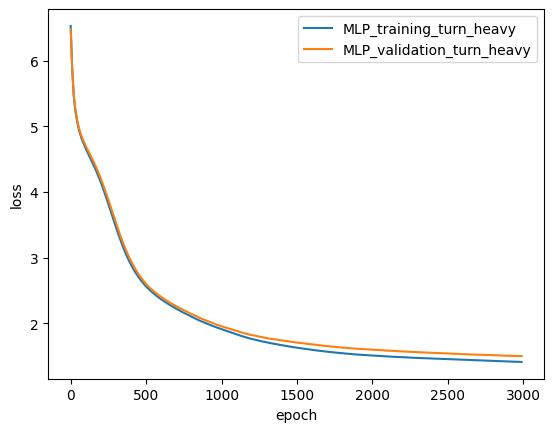

RNN Trainer final loss: 0.8767789006233215
RNN Validator final loss: 1.0270472764968872


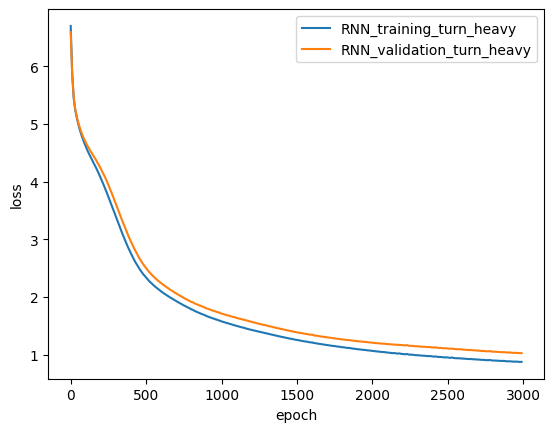

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559
MLP Trainer final loss: 1.4699786901474
MLP Validator final loss: 1.4350517988204956


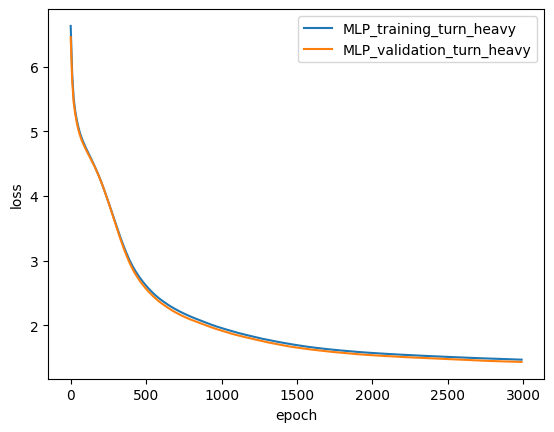

RNN Trainer final loss: 0.8717593550682068
RNN Validator final loss: 0.9104355573654175


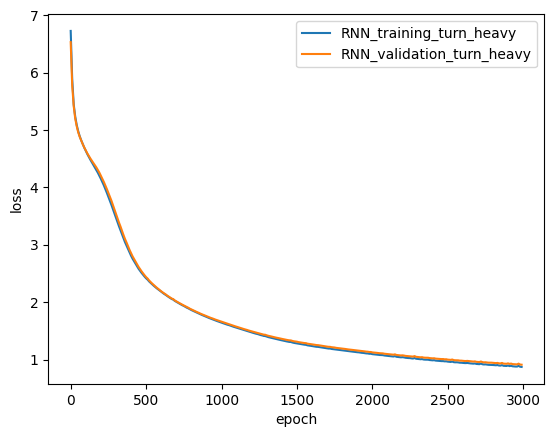

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559
MLP Trainer final loss: 1.4892499446868896
MLP Validator final loss: 1.4407180547714233


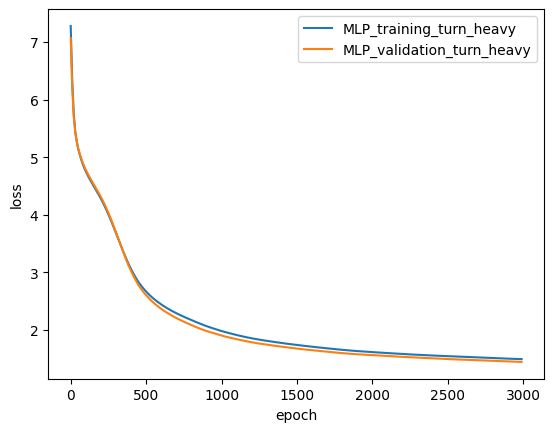

RNN Trainer final loss: 0.8392442464828491
RNN Validator final loss: 0.8464289903640747


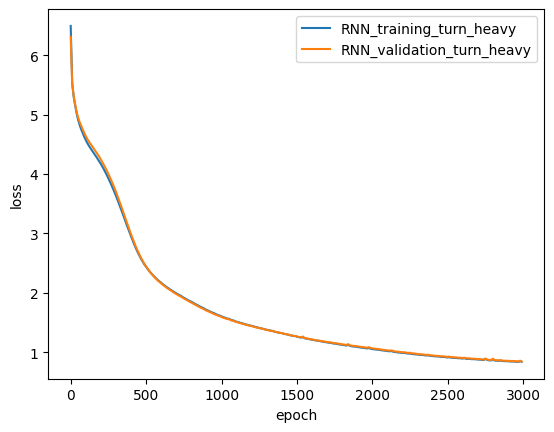

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559


,0,1,2
Trajectory count,20.000000,40.000000,80.000000
Trainer MLP Loss,1.409606,1.469979,1.489250
Trainer RNN Loss,0.876779,0.871759,0.839244
Validator MLP Loss,1.497483,1.435052,1.440718
Validator RNN Loss,1.027047,0.910436,0.846429


In [62]:
traj_num = N_TRAJ

traj_list_turn_heavy = []
trainer_MLP_turn_heavy_loss_list = []
trainer_RNN_turn_heavy_loss_list = []
validator_MLP_turn_heavy_loss_list = []
validator_RNN_turn_heavy_loss_list = []
for i in range(3):
    #Generate turn heavy trainer and validator agents

    trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, trainer_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, traj_num, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
    validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, validator_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

    #Train MLP

    INPUT_SIZE_TURN_HEAVY = trainer_inputs_stack_turn_heavy.shape[2]
    OUTPUT_SIZE_TURN_HEAVY = trainer_target_stack_turn_heavy.shape[2]
    HIDDEN_SIZE_TURN_HEAVY = 64     

    model_MLP_turn_heavy = NN_models.SimpleMLP(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")
    MLP_turn_heavy_loss_info = model_training_evaluator.model_training(model_MLP_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, TRAINING_EPOCHS)
    print(f"MLP Trainer final loss: {MLP_turn_heavy_loss_info[1][-1]}")
    print(f"MLP Validator final loss: {MLP_turn_heavy_loss_info[2][-1]}")
    
    trainer_MLP_turn_heavy_loss_list.append(MLP_turn_heavy_loss_info[1][-1])
    validator_MLP_turn_heavy_loss_list.append(MLP_turn_heavy_loss_info[2][-1])


    model_training_evaluator.plot_training_result(MLP_turn_heavy_loss_info, "epoch", "loss", "MLP_training_turn_heavy", "MLP_validation_turn_heavy")

    #Train RNN

    model_RNN_turn_heavy = NN_models.BasicRNN(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")
    RNN_turn_heavy_loss_info = model_training_evaluator.model_training(model_RNN_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, TRAINING_EPOCHS)
    print(f"RNN Trainer final loss: {RNN_turn_heavy_loss_info[1][-1]}")
    print(f"RNN Validator final loss: {RNN_turn_heavy_loss_info[2][-1]}")

    model_training_evaluator.plot_training_result(RNN_turn_heavy_loss_info, "epoch", "loss", "RNN_training_turn_heavy", "RNN_validation_turn_heavy")


    trainer_RNN_turn_heavy_loss_list.append(RNN_turn_heavy_loss_info[1][-1])
    validator_RNN_turn_heavy_loss_list.append(RNN_turn_heavy_loss_info[2][-1])


    #Baseline Loss Evaluation

    model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)
    model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

    traj_num *= 2

results_turn_heavy_table_array = []

results_turn_heavy_table_array.append(traj_list)
results_turn_heavy_table_array.append(trainer_MLP_turn_heavy_loss_list)
results_turn_heavy_table_array.append(trainer_RNN_turn_heavy_loss_list)
results_turn_heavy_table_array.append(validator_MLP_turn_heavy_loss_list)
results_turn_heavy_table_array.append(validator_RNN_turn_heavy_loss_list)

results_turn_heavy = pd.DataFrame(
    results_turn_heavy_table_array,
    index = ["Trajectory count", "Trainer MLP Loss", "Trainer RNN Loss", "Validator MLP Loss", "Validator RNN Loss"]
)

results_turn_heavy

Validator Error per Action Type

In [72]:
results_array = []

trainer_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, validator_inputs_stack, validator_target_stack)

trainer_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, trainer_inputs_stack, trainer_target_stack)
validator_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, validator_inputs_stack, validator_target_stack)

results_array.append(trainer_RNN_action_losses)
results_array.append(trainer_MLP_action_losses)
results_array.append(validator_RNN_action_losses)
results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    results_array,
    index = ["trainer, RNN", "trainer, MLP", "validator, RNN", "validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

,Forward,Left,Right,Stop
"trainer, RNN",0.322463,1.521198,1.483456,1.017189
"trainer, MLP",0.257910,2.026531,2.078107,0.714002
"validator, RNN",0.376541,1.637915,1.760719,1.064824
"validator, MLP",0.299441,2.318960,2.342318,0.781298


Memoryless RNN: How does RNN perform if the hidden state is reset at every step?

In [73]:
memoryless_results_array = []
trainer_RNN_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, validator_inputs_stack, validator_target_stack)


trainer_RNN_turn_heavy_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy)
validator_RNN_turn_heavy_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

memoryless_results_array.append(trainer_RNN_action_losses)
memoryless_results_array.append(trainer_RNN_memoryless_per_action_loss)
memoryless_results_array.append(trainer_MLP_action_losses)
memoryless_results_array.append(validator_RNN_action_losses)
memoryless_results_array.append(validator_RNN_memoryless_per_action_loss)
memoryless_results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    memoryless_results_array,
    index = ["trainer, RNN", "Trainer RNN Memoryless", "trainer, MLP", "validator, RNN", "Validator RNN Memoryless", "Validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

No samples for 3
No samples for 3


,Forward,Left,Right,Stop
"trainer, RNN",0.322463,1.521198,1.483456,1.017189
Trainer RNN Memoryless,0.863358,3.768028,3.793619,1.523542
"trainer, MLP",0.257910,2.026531,2.078107,0.714002
"validator, RNN",0.376541,1.637915,1.760719,1.064824
Validator RNN Memoryless,0.949287,4.008194,3.966243,1.546019
"Validator, MLP",0.299441,2.318960,2.342318,0.781298
